<a href="https://colab.research.google.com/github/aqib-ali-29184/pdc-feature-selection/blob/milestone-1/feature_selection_milestone1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Loading Datasets (mnist, cifar10_gray, madelon)

In [18]:
class DatasetLoader:
    """
    Handles loading, preprocessing, and splitting of datasets.
    Designed for feature selection experiments.
    """

    def __init__(self, dataset_name: str):
        self.dataset_name = dataset_name
        self.X = None
        self.y = None
        self.feature_names = None

    def load(self):
        print(f"\n📦 Loading dataset: {self.dataset_name} ...")

        if self.dataset_name == "mnist":
            data = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
            self.X = data.data.astype(np.float32)
            self.y = data.target.astype(int)
            self.feature_names = [f"pixel_{i}" for i in range(self.X.shape[1])]

        elif self.dataset_name == "cifar10_gray":
            from keras.datasets import cifar10
            import cv2
            (X_train, y_train), (X_test, y_test) = cifar10.load_data()
            # Convert to grayscale and flatten → 1024 features
            X_all = np.concatenate([X_train, X_test], axis=0)
            y_all = np.concatenate([y_train.flatten(), y_test.flatten()], axis=0)
            X_gray = np.array([
                cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).flatten()
                for img in X_all
            ], dtype=np.float32)
            self.X = X_gray
            self.y = y_all
            self.feature_names = [f"pixel_{i}" for i in range(self.X.shape[1])]

        elif self.dataset_name == "madelon":
            data = fetch_openml('madelon', version=1, as_frame=False, parser='auto')
            self.X = data.data.astype(np.float32)
            self.y = (data.target.astype(int) > 0).astype(int)  # binary
            self.feature_names = [f"feat_{i}" for i in range(self.X.shape[1])]

        else:
            raise ValueError(f"Unknown dataset: {self.dataset_name}")

        print(f"   Shape     : {self.X.shape}")
        print(f"   Classes   : {np.unique(self.y)}")
        print(f"   Features  : {self.X.shape[1]}")
        return self

    def preprocess(self, sample_size=None):
        """Scale features to [0,1]. Optionally subsample for speed."""
        if sample_size and sample_size < len(self.X):
            idx = np.random.choice(len(self.X), sample_size, replace=False)
            self.X = self.X[idx]
            self.y = self.y[idx]
            print(f"   Subsampled to {sample_size} samples")

        scaler = MinMaxScaler()
        self.X = scaler.fit_transform(self.X)
        print(f"   ✅ Preprocessing done. Feature range: [{self.X.min():.2f}, {self.X.max():.2f}]")
        return self

    def split(self, test_size=0.2, random_state=42):
        X_train, X_test, y_train, y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=random_state, stratify=self.y
        )
        print(f"   Train: {X_train.shape}, Test: {X_test.shape}")
        return X_train, X_test, y_train, y_test

Naive Bayes model for evaluation

In [19]:
class NaiveBayesEvaluator:
    """
    Wraps GaussianNaiveBayes for use as the ML evaluator
    in the feature selection pipeline.
    This will be called by the Fitness Function
    """

    def __init__(self):
        self.model = GaussianNB()

    def evaluate(self, X_train, X_test, y_train, y_test, feature_mask=None):
        """
        Evaluate accuracy using a binary feature mask.
        feature_mask: array of 0s and 1s (e.g., [1,0,1,1,...])
                      If None, uses ALL features (baseline).
        Returns: accuracy (float), time_taken (float)
        """
        if feature_mask is not None:
            selected = np.where(np.array(feature_mask) == 1)[0]
            if len(selected) == 0:
                return 0.0, 0.0
            X_tr = X_train[:, selected]
            X_te = X_test[:, selected]
        else:
            X_tr, X_te = X_train, X_test

        start = time.time()
        self.model.fit(X_tr, y_train)
        preds = self.model.predict(X_te)
        elapsed = time.time() - start

        acc = accuracy_score(y_test, preds)
        return acc, elapsed

Loading and Pre-processing Datasets

In [20]:
# ─────────────────────────────────────────────
# 1. DATASET LOADER
# ─────────────────────────────────────────────
class DatasetLoader:
    def __init__(self, dataset_name: str):
        self.dataset_name = dataset_name
        self.X = None
        self.y = None

    def load(self):
        print(f"\n📦 Loading dataset: {self.dataset_name} ...")

        if self.dataset_name == "mnist":
          from keras.datasets import mnist
          (X_train, y_train), (X_test, y_test) = mnist.load_data()
          X_all = np.concatenate([X_train, X_test], axis=0)
          y_all = np.concatenate([y_train, y_test], axis=0)
          # Flatten 28x28 images into 784 features
          self.X = X_all.reshape(X_all.shape[0], -1).astype(np.float32)
          self.y = y_all.astype(int)

        elif self.dataset_name == "cifar10_gray":
            from keras.datasets import cifar10
            import cv2
            (X_train, y_train), (X_test, y_test) = cifar10.load_data()
            X_all = np.concatenate([X_train, X_test], axis=0)
            y_all = np.concatenate([y_train.flatten(), y_test.flatten()], axis=0)
            self.X = np.array([
                cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).flatten()
                for img in X_all
            ], dtype=np.float32)
            self.y = y_all

        elif self.dataset_name == "madelon":
            from sklearn.datasets import make_classification
            X, y = make_classification(
                n_samples=2600,
                n_features=500,
                n_informative=20,
                n_redundant=480,
                n_classes=2,
                random_state=42
            )
            self.X = X.astype(np.float32)
            self.y = y.astype(int)

        else:
            raise ValueError(f"Unknown dataset: {self.dataset_name}")

        print(f"   Shape     : {self.X.shape}")
        print(f"   Classes   : {np.unique(self.y)}")
        print(f"   Features  : {self.X.shape[1]}")
        return self

    def preprocess(self, sample_size=None):
        if sample_size and sample_size < len(self.X):
            np.random.seed(42)
            idx = np.random.choice(len(self.X), sample_size, replace=False)
            self.X = self.X[idx]
            self.y = self.y[idx]
            print(f"   Subsampled to {sample_size} samples")

        scaler = MinMaxScaler()
        self.X = scaler.fit_transform(self.X)
        print(f"   ✅ Preprocessing done. Feature range: [{self.X.min():.2f}, {self.X.max():.2f}]")
        return self

    def split(self, test_size=0.2, random_state=42):
        X_train, X_test, y_train, y_test = train_test_split(
            self.X, self.y,
            test_size=test_size,
            random_state=random_state,
            stratify=self.y
        )
        print(f"   Train: {X_train.shape}, Test: {X_test.shape}")
        return X_train, X_test, y_train, y_test



Naive Bayes Evaluator

In [21]:
# ─────────────────────────────────────────────
# 2. NAIVE BAYES EVALUATOR
# ─────────────────────────────────────────────
class NaiveBayesEvaluator:
    def __init__(self):
        self.model = GaussianNB()

    def evaluate(self, X_train, X_test, y_train, y_test, feature_mask=None):
        if feature_mask is not None:
            selected = np.where(np.array(feature_mask) == 1)[0]
            if len(selected) == 0:
                return 0.0, 0.0
            X_tr = X_train[:, selected]
            X_te = X_test[:, selected]
        else:
            X_tr, X_te = X_train, X_test

        start = time.time()
        self.model.fit(X_tr, y_train)
        preds = self.model.predict(X_te)
        elapsed = time.time() - start

        acc = accuracy_score(y_test, preds)
        return acc, elapsed


# ─────────────────────────────────────────────
# 3. BASELINE RUNNER
# ─────────────────────────────────────────────
def run_baseline(dataset_name, sample_size=5000):
    print(f"\n{'='*50}")
    print(f"  BASELINE: {dataset_name.upper()}")
    print(f"{'='*50}")

    loader = DatasetLoader(dataset_name)
    loader.load().preprocess(sample_size=sample_size)
    X_train, X_test, y_train, y_test = loader.split()

    evaluator = NaiveBayesEvaluator()
    acc, t = evaluator.evaluate(X_train, X_test, y_train, y_test, feature_mask=None)

    # Sanity check — print both train and test accuracy for madelon
    if dataset_name == "madelon":
        train_acc = accuracy_score(y_train, evaluator.model.predict(X_train))
        print(f"\n🔍 Sanity Check:")
        print(f"   Train Accuracy : {train_acc * 100:.2f}%")
        print(f"   Test  Accuracy : {acc * 100:.2f}%")

    print(f"\n📊 Results (ALL {X_train.shape[1]} features):")
    print(f"   Accuracy : {acc * 100:.2f}%")
    print(f"   Time     : {t:.4f}s")

    return {
        "dataset": dataset_name,
        "n_features": X_train.shape[1],
        "accuracy_full": acc,
        "time_full": t,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }


# ─────────────────────────────────────────────
# 4. RUN ALL 3 DATASETS
# ─────────────────────────────────────────────
results = {}
results["mnist"]        = run_baseline("mnist",        sample_size=5000)
results["madelon"]      = run_baseline("madelon",      sample_size=None)
results["cifar10_gray"] = run_baseline("cifar10_gray", sample_size=5000)



  BASELINE: MNIST

📦 Loading dataset: mnist ...
   Shape     : (70000, 784)
   Classes   : [0 1 2 3 4 5 6 7 8 9]
   Features  : 784
   Subsampled to 5000 samples
   ✅ Preprocessing done. Feature range: [0.00, 1.00]
   Train: (4000, 784), Test: (1000, 784)

📊 Results (ALL 784 features):
   Accuracy : 58.70%
   Time     : 0.0596s

  BASELINE: MADELON

📦 Loading dataset: madelon ...
   Shape     : (2600, 500)
   Classes   : [0 1]
   Features  : 500
   ✅ Preprocessing done. Feature range: [0.00, 1.00]
   Train: (2080, 500), Test: (520, 500)

🔍 Sanity Check:
   Train Accuracy : 86.54%
   Test  Accuracy : 84.04%

📊 Results (ALL 500 features):
   Accuracy : 84.04%
   Time     : 0.0210s

  BASELINE: CIFAR10_GRAY

📦 Loading dataset: cifar10_gray ...
   Shape     : (60000, 1024)
   Classes   : [0 1 2 3 4 5 6 7 8 9]
   Features  : 1024
   Subsampled to 5000 samples
   ✅ Preprocessing done. Feature range: [0.00, 1.00]
   Train: (4000, 1024), Test: (1000, 1024)

📊 Results (ALL 1024 features):
   A

Summary Table

In [22]:
summary = pd.DataFrame([{
    "Dataset":           r["dataset"],
    "Num Features":      r["n_features"],
    "Full Accuracy (%)": round(r["accuracy_full"] * 100, 2),
    "Time (s)":          round(r["time_full"], 4)
} for r in results.values()])

print("\n📋 BASELINE SUMMARY TABLE")
print(summary.to_string(index=False))

summary.to_csv("baseline_results.csv", index=False)
print("\n✅ Saved to baseline_results.csv")


📋 BASELINE SUMMARY TABLE
     Dataset  Num Features  Full Accuracy (%)  Time (s)
       mnist           784              58.70    0.0596
     madelon           500              84.04    0.0210
cifar10_gray          1024              22.70    0.0614

✅ Saved to baseline_results.csv


In [23]:
# ─────────────────────────────────────────────────────────────
# 1. BINARY MASK ENCODING
# ─────────────────────────────────────────────────────────────

class BinaryMaskEncoder:
    """
    Represents feature subsets as binary masks.
    A mask is an array like [1, 0, 1, 1, 0, ...] where:
      1 = keep this feature
      0 = drop this feature
    """

    def __init__(self, n_features: int):
        """
        n_features: total number of features in the dataset
                    e.g. 784 for MNIST, 500 for Madelon, 1024 for CIFAR-10
        """
        self.n_features = n_features

    def all_ones(self):
        """Returns a mask with ALL features selected (baseline)."""
        return np.ones(self.n_features, dtype=int)

    def all_zeros(self):
        """Returns a mask with NO features selected."""
        return np.zeros(self.n_features, dtype=int)

    def random_mask(self, density=0.5, seed=None):
        """
        Returns a random mask.
        density: probability that each feature is set to 1
                 e.g. 0.5 means roughly half the features are selected
        """
        if seed is not None:
            np.random.seed(seed)
        return (np.random.rand(self.n_features) < density).astype(int)

    def flip_bit(self, mask, index):
        """
        Flips a single bit in the mask at position 'index'.
        If it was 1, it becomes 0. If it was 0, it becomes 1.
        Returns a NEW mask (does not change the original).
        """
        new_mask = mask.copy()
        new_mask[index] = 1 - new_mask[index]  # flip: 0→1 or 1→0
        return new_mask

    def count_active(self, mask):
        """Returns how many features are currently selected (how many 1s)."""
        return int(np.sum(mask))

    def get_active_indices(self, mask):
        """Returns the positions of all selected features (where mask == 1)."""
        return np.where(np.array(mask) == 1)[0]

    def mask_to_string(self, mask):
        """Converts mask to a compact string like '101101...' for logging."""
        return ''.join(map(str, mask))

In [24]:
# ─────────────────────────────────────────────────────────────
# 2. FITNESS FUNCTION
# ─────────────────────────────────────────────────────────────

class FitnessFunction:
    """
    Scores a binary mask based on:
      - Accuracy from NaiveBayes (higher = better)
      - Number of features used (fewer = better)

    Final score = accuracy - (alpha * feature_ratio)
    where feature_ratio = selected_features / total_features

    alpha controls how much we penalize using many features.
    A higher alpha = we care more about reducing features.
    """

    def __init__(self, evaluator: NaiveBayesEvaluator, alpha=0.01):
        """
        evaluator : an instance of NaiveBayesEvaluator (Aqib's class)
        alpha     : penalty weight for number of features used
                    default 0.01 means slight preference for fewer features
        """
        self.evaluator = evaluator
        self.alpha = alpha

    def evaluate(self, mask, X_train, X_test, y_train, y_test):
        """
        Given a binary mask, calculate its fitness score.

        Returns:
          score       : fitness value (higher is better)
          accuracy    : raw classification accuracy
          n_selected  : number of features used
          time_taken  : how long evaluation took
        """
        mask = np.array(mask)
        n_total    = len(mask)
        n_selected = int(np.sum(mask))

        # If no features are selected, return worst possible score
        if n_selected == 0:
            return 0.0, 0.0, 0, 0.0

        # Get accuracy from evaluator
        accuracy, time_taken = self.evaluator.evaluate(
            X_train, X_test, y_train, y_test,
            feature_mask=mask
        )

        # feature_ratio: what fraction of features are we using?
        # e.g. 100 out of 784 = 0.127
        feature_ratio = n_selected / n_total

        # Fitness score: reward accuracy, penalize using too many features
        score = accuracy - (self.alpha * feature_ratio)

        return score, accuracy, n_selected, time_taken

In [25]:
# ─────────────────────────────────────────────────────────────
# 3. RESULTS LOGGER
# ─────────────────────────────────────────────────────────────

class ResultsLogger:
    """
    Tracks and saves the performance of every mask that gets evaluated.
    Hasan will use this data to compare against his sequential search.
    """

    def __init__(self, dataset_name: str):
        self.dataset_name = dataset_name
        self.records = []  # list of dicts, one per evaluation

    def log(self, mask, score, accuracy, n_selected, time_taken, label=""):
        """
        Log one evaluation result.

        mask        : the binary mask that was tested
        score       : fitness score
        accuracy    : classification accuracy (0 to 1)
        n_selected  : number of features selected
        time_taken  : evaluation time in seconds
        label       : optional tag like 'random', 'all_features', etc.
        """
        encoder = BinaryMaskEncoder(len(mask))
        self.records.append({
            "dataset"    : self.dataset_name,
            "label"      : label,
            "score"      : round(score, 6),
            "accuracy"   : round(accuracy, 6),
            "n_selected" : n_selected,
            "n_total"    : len(mask),
            "feature_%"  : round(100 * n_selected / len(mask), 2),
            "time_s"     : round(time_taken, 6),
            "mask_str"   : encoder.mask_to_string(mask)
        })

    def get_best(self):
        """Returns the single best result logged so far (highest score)."""
        if not self.records:
            return None
        return max(self.records, key=lambda r: r["score"])

    def to_dataframe(self):
        """Returns all logged results as a pandas DataFrame."""
        return pd.DataFrame(self.records)

    def save_csv(self, filename=None):
        """Saves all results to a CSV file."""
        if filename is None:
            filename = f"fitness_results_{self.dataset_name}.csv"
        df = self.to_dataframe()
        df.to_csv(filename, index=False)
        print(f"✅ Saved {len(df)} results to '{filename}'")
        return filename

    def print_summary(self):
        """Prints a clean summary of all evaluations."""
        df = self.to_dataframe()
        if df.empty:
            print("No results logged yet.")
            return

        print(f"\n📋 RESULTS SUMMARY — {self.dataset_name.upper()}")
        print(f"   Total evaluations : {len(df)}")
        print(f"   Best accuracy     : {df['accuracy'].max()*100:.2f}%")
        print(f"   Best score        : {df['score'].max():.6f}")
        print(f"   Avg features used : {df['n_selected'].mean():.1f} / {df['n_total'].iloc[0]}")
        print(f"\n   Top 5 results:")
        top5 = df.nlargest(5, 'score')[['label','accuracy','n_selected','feature_%','score','time_s']]
        print(top5.to_string(index=False))

In [26]:
# ─────────────────────────────────────────────────────────────
# 4. DEMO — Run on all 3 datasets
# ─────────────────────────────────────────────────────────────

def run_fitness_demo(dataset_name, result_dict, n_random_masks=10, seed=42):
    """
    Demonstrates the fitness function on a dataset by testing:
      - All features (baseline mask)
      - Several random masks
    """
    print(f"\n{'='*55}")
    print(f"  FITNESS DEMO: {dataset_name.upper()}")
    print(f"{'='*55}")

    # Unpack data
    X_train = result_dict["X_train"]
    X_test  = result_dict["X_test"]
    y_train = result_dict["y_train"]
    y_test  = result_dict["y_test"]
    n_features = X_train.shape[1]

    # Set up three components
    encoder  = BinaryMaskEncoder(n_features)
    evaluator = NaiveBayesEvaluator()
    fitness  = FitnessFunction(evaluator, alpha=0.01)
    logger   = ResultsLogger(dataset_name)

    # Test 1: All features
    mask_all = encoder.all_ones()
    score, acc, n_sel, t = fitness.evaluate(mask_all, X_train, X_test, y_train, y_test)
    logger.log(mask_all, score, acc, n_sel, t, label="all_features")
    print(f"\n✅ All features   → Accuracy: {acc*100:.2f}%  Score: {score:.4f}  Features: {n_sel}/{n_features}")

    # Test 2: random masks
    np.random.seed(seed)
    print(f"\n Testing {n_random_masks} random masks (50% density)...")
    for i in range(n_random_masks):
        mask = encoder.random_mask(density=0.5)
        score, acc, n_sel, t = fitness.evaluate(mask, X_train, X_test, y_train, y_test)
        logger.log(mask, score, acc, n_sel, t, label=f"random_{i+1}")
        print(f"   Mask {i+1:2d}: Accuracy={acc*100:.2f}%  Features={n_sel}/{n_features}  Score={score:.4f}")

    # Print summary and save
    logger.print_summary()
    logger.save_csv()

    return logger


# RUN ON ALL 3 DATASETS

fitness_loggers = {}
for ds_name in ["mnist", "madelon", "cifar10_gray"]:
    fitness_loggers[ds_name] = run_fitness_demo(
        dataset_name  = ds_name,
        result_dict   = results[ds_name],
        n_random_masks= 10
    )

print("\n\n🎉 All CSV files saved")


  FITNESS DEMO: MNIST

✅ All features   → Accuracy: 58.70%  Score: 0.5770  Features: 784/784

 Testing 10 random masks (50% density)...
   Mask  1: Accuracy=59.30%  Features=387/784  Score=0.5881
   Mask  2: Accuracy=52.70%  Features=388/784  Score=0.5221
   Mask  3: Accuracy=59.30%  Features=385/784  Score=0.5881
   Mask  4: Accuracy=58.50%  Features=395/784  Score=0.5800
   Mask  5: Accuracy=53.80%  Features=395/784  Score=0.5330
   Mask  6: Accuracy=57.90%  Features=389/784  Score=0.5740
   Mask  7: Accuracy=55.90%  Features=416/784  Score=0.5537
   Mask  8: Accuracy=55.40%  Features=394/784  Score=0.5490
   Mask  9: Accuracy=54.30%  Features=404/784  Score=0.5378
   Mask 10: Accuracy=55.90%  Features=403/784  Score=0.5539

📋 RESULTS SUMMARY — MNIST
   Total evaluations : 11
   Best accuracy     : 59.30%
   Best score        : 0.588089
   Avg features used : 430.9 / 784

   Top 5 results:
       label  accuracy  n_selected  feature_%    score   time_s
    random_3     0.593        

In [27]:
# ============================================================
# SEQUENTIAL HILL-CLIMBING SEARCH
# ============================================================

class SequentialHillClimbSearch:
    """
    Sequential Hill-Climbing Feature Selection using binary masks.

    Mutation strategy: flip `n_flips` random bits per iteration
    (combined Add + Remove step). In Milestone 2 these will be
    split into competing parallel operators:
        Adder   → flips 0→1 only
        Remover → flips 1→0 only

    Args:
        fitness_fn   (FitnessFunction) : Ayesha's fitness evaluator
        n_iterations (int)             : Search iterations per dataset
        n_flips      (int)             : Bits flipped per mutation
        init_ratio   (float)           : Fraction of features active at start
        random_state (int)             : Seed for reproducibility
    """

    def __init__(self, fitness_fn, n_iterations=100,
                 n_flips=10, init_ratio=0.5, random_state=42):
        # ──: store FitnessFunction
        self.fitness_fn   = fitness_fn
        self.n_iterations = n_iterations
        self.n_flips      = n_flips
        self.init_ratio   = init_ratio
        self.random_state = random_state

    # ── Internal Helpers ────────────

    def _init_mask(self, n_features):
        """
        Random starting binary mask.
        init_ratio controls starting density (default 50% features active).
        """
        np.random.seed(self.random_state)
        mask = np.zeros(n_features, dtype=int)
        n_active = max(1, int(n_features * self.init_ratio))
        active_indices = np.random.choice(n_features, n_active, replace=False)
        mask[active_indices] = 1
        return mask

    def _mutate(self, mask):
        """
        Flip `n_flips` random bits (0→1 or 1→0).
        Guards against an all-zero mask after mutation.
        """
        n_features = len(mask)
        mutated = mask.copy()
        flip_indices = np.random.choice(n_features, self.n_flips, replace=False)
        for idx in flip_indices:
            mutated[idx] = 1 - mutated[idx]
        if mutated.sum() == 0:
            mutated[np.random.randint(n_features)] = 1
        return mutated

    # ── Main Search Loop ──────────────────────────────────────

    def search(self, X_train, X_test, y_train, y_test, dataset_name="dataset"):
        """
        Run the hill-climbing search for `n_iterations` steps.

        Args:
            X_train, X_test, y_train, y_test : data splits
            dataset_name (str) : passed to ResultsLogger for labelling

        Returns:
            best_mask  (np.array)    : binary mask of best found subset
            best_score (float)       : best fitness score achieved
            logger     (ResultsLogger): full log of all iterations
        """
        n_features = X_train.shape[1]
        np.random.seed(self.random_state)

        # ──: instantiate ResultsLogger for this dataset
        logger = ResultsLogger(dataset_name)

        print(f"\n{'='*55}")
        print(f"  SEQUENTIAL SEARCH — {dataset_name.upper()}")
        print(f"  Features: {n_features} | Iterations: {self.n_iterations}"
              f" | Flips/iter: {self.n_flips}")
        print(f"{'='*55}")

        # ── Initialise ────────────────────────────────────────
        current_mask = self._init_mask(n_features)

        # ──: call fitness.evaluate() → 4 return values
        current_score, current_acc, current_n_sel, current_time = \
            self.fitness_fn.evaluate(
                current_mask, X_train, X_test, y_train, y_test
            )

        # Log the starting mask
        logger.log(current_mask, current_score, current_acc,
                   current_n_sel, current_time, label="init")

        best_mask  = current_mask.copy()
        best_score = current_score   # ← track best SCORE

        # ── Search Loop ───────────────────────────────────────
        for i in range(1, self.n_iterations + 1):

            # 1. Mutate
            candidate_mask = self._mutate(current_mask)

            # 2. Evaluate —: use fitness_fn, unpack 4 values
            cand_score, cand_acc, cand_n_sel, cand_time = \
                self.fitness_fn.evaluate(
                    candidate_mask, X_train, X_test, y_train, y_test
                )

            # 3. Greedy accept —: compare SCORES
            improved = cand_score > current_score
            if improved:
                current_mask  = candidate_mask.copy()
                current_score = cand_score

            # 4. Track global best by score
            if cand_score > best_score:
                best_score = cand_score
                best_mask  = candidate_mask.copy()

            # 5. delegate to ResultsLogger
            label = f"iter_{i}_accepted" if improved else f"iter_{i}"
            logger.log(candidate_mask, cand_score, cand_acc,
                       cand_n_sel, cand_time, label=label)

            # 6. Progress print every 10 iterations
            if i % 10 == 0 or i == 1:
                print(f"  Iter {i:>3} | "
                      f"Subset: {cand_n_sel:>4} feats | "
                      f"Acc: {cand_acc*100:.2f}% | "
                      f"Score: {cand_score:.4f} | "
                      f"Best Score: {best_score:.4f} | "
                      f"{'✅ improved' if improved else '↩ reverted'}")

        # print summary via logger's built-in method
        logger.print_summary()

        return best_mask, best_score, logger


print("SequentialHillClimbSearch class defined.")

SequentialHillClimbSearch class defined.


In [28]:
# ============================================================
# RUN SEQUENTIAL SEARCH ON ALL 3 DATASETS
# ============================================================

SEARCH_CONFIG = {
    'mnist':        {'n_iterations': 100, 'n_flips': 15, 'init_ratio': 0.5},
    'madelon':      {'n_iterations': 100, 'n_flips': 10, 'init_ratio': 0.5},
    'cifar10_gray': {'n_iterations': 100, 'n_flips': 20, 'init_ratio': 0.5},
}

search_results = {}
search_loggers = {}

total_start = time.time()

for dataset_name, config in SEARCH_CONFIG.items():

    # using results
    data = results[dataset_name]

    # Layer 1: raw ML model
    evaluator = NaiveBayesEvaluator()
    # Layer 2: penalized fitness wrapper
    fitness_fn = FitnessFunction(evaluator, alpha=0.01)

    searcher = SequentialHillClimbSearch(
        fitness_fn   = fitness_fn,
        n_iterations = config['n_iterations'],
        n_flips      = config['n_flips'],
        init_ratio   = config['init_ratio'],
        random_state = 42
    )

    best_mask, best_score, logger = searcher.search(
        data['X_train'], data['X_test'],
        data['y_train'], data['y_test'],
        dataset_name=dataset_name
    )

    best_record = logger.get_best()
    search_results[dataset_name] = {
        'best_mask'    : best_mask,
        'best_score'   : best_score,
        'best_acc'     : best_record['accuracy'],
        'best_n_feats' : best_record['n_selected'],
        'n_features'   : data['X_train'].shape[1]
    }
    search_loggers[dataset_name] = logger

total_time = time.time() - total_start

print(f"\n{'='*55}")
print(f"  ALL SEARCHES COMPLETE — Total time: {total_time:.1f}s")
print(f"{'='*55}")

print(f"\n{'Dataset':<15} {'Best Score':>11} {'Best Acc':>10} {'Features Used':>15} {'Total':>8}")
print("-" * 62)
for name, res in search_results.items():
    print(f"{name:<15} "
          f"{res['best_score']:>11.4f} "
          f"{res['best_acc']*100:>9.2f}% "
          f"{res['best_n_feats']:>15} "
          f"{res['n_features']:>8}")


  SEQUENTIAL SEARCH — MNIST
  Features: 784 | Iterations: 100 | Flips/iter: 15
  Iter   1 | Subset:  397 feats | Acc: 59.50% | Score: 0.5899 | Best Score: 0.5899 | ✅ improved
  Iter  10 | Subset:  406 feats | Acc: 62.10% | Score: 0.6158 | Best Score: 0.6158 | ✅ improved
  Iter  20 | Subset:  406 feats | Acc: 64.20% | Score: 0.6368 | Best Score: 0.6368 | ✅ improved
  Iter  30 | Subset:  409 feats | Acc: 63.40% | Score: 0.6288 | Best Score: 0.6448 | ↩ reverted
  Iter  40 | Subset:  405 feats | Acc: 65.30% | Score: 0.6478 | Best Score: 0.6518 | ↩ reverted
  Iter  50 | Subset:  407 feats | Acc: 66.00% | Score: 0.6548 | Best Score: 0.6548 | ✅ improved
  Iter  60 | Subset:  396 feats | Acc: 64.20% | Score: 0.6369 | Best Score: 0.6619 | ↩ reverted
  Iter  70 | Subset:  398 feats | Acc: 68.00% | Score: 0.6749 | Best Score: 0.6749 | ✅ improved
  Iter  80 | Subset:  395 feats | Acc: 67.80% | Score: 0.6730 | Best Score: 0.6820 | ↩ reverted
  Iter  90 | Subset:  393 feats | Acc: 69.10% | Score: 0

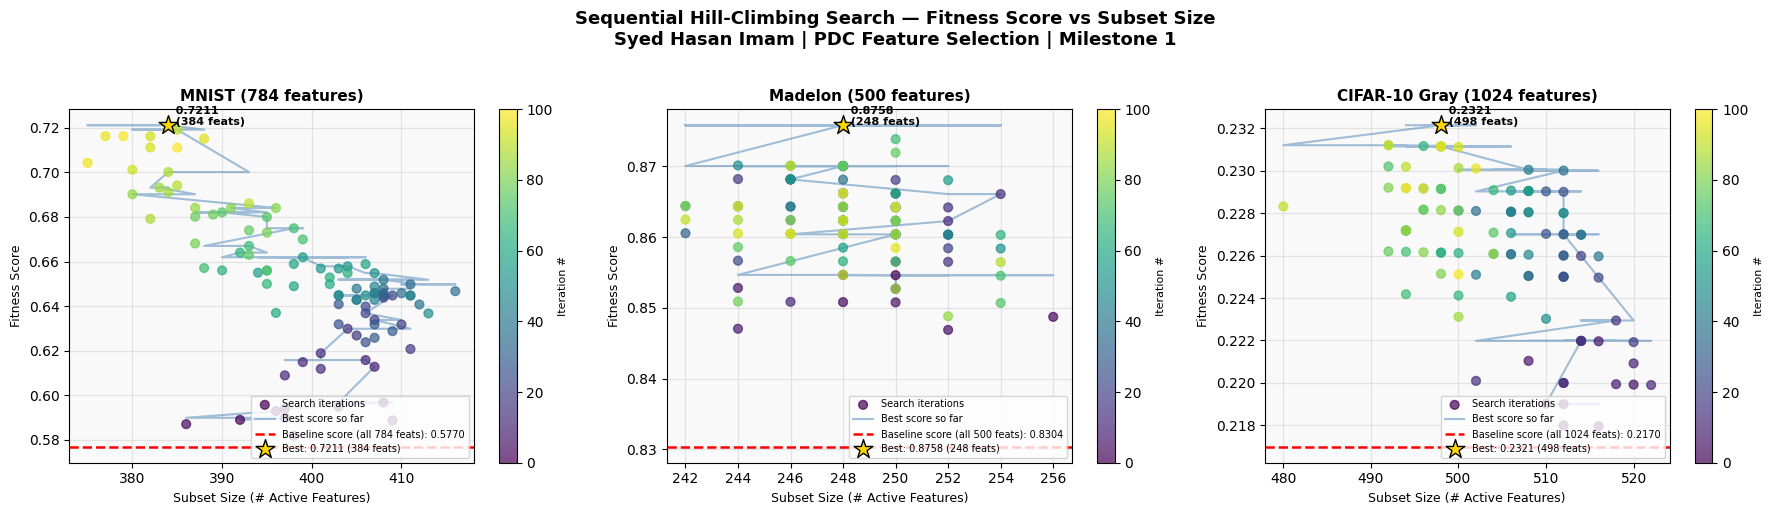

✅ Plot saved as sequential_search_plots.png


In [29]:
# ============================================================
# VISUALIZATIONS: Fitness Score vs Subset Size
# ============================================================

DATASET_LABELS = {
    'mnist':        'MNIST (784 features)',
    'madelon':      'Madelon (500 features)',
    'cifar10_gray': 'CIFAR-10 Gray (1024 features)',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Sequential Hill-Climbing Search — Fitness Score vs Subset Size\n'
    'Syed Hasan Imam | PDC Feature Selection | Milestone 1',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, dataset_name in zip(axes, ['mnist', 'madelon', 'cifar10_gray']):

    history  = search_loggers[dataset_name].to_dataframe()
    result   = search_results[dataset_name]

    # ── Pull baseline score from results dict
    b_acc      = results[dataset_name]['accuracy_full']
    n_features = results[dataset_name]['n_features']
    # Baseline score: all features → feature_ratio = 1.0
    b_score    = b_acc - (0.01 * 1.0)

    x = history['n_selected']
    y = history['score']           # ← fitness score

    scatter = ax.scatter(
        x, y,
        c=history.index,
        cmap='viridis',
        alpha=0.7, s=40, zorder=3,
        label='Search iterations'
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Iteration #', fontsize=8)

    # Rolling best fitness score line
    history['best_score_so_far'] = history['score'].cummax()
    ax.plot(
        history['n_selected'],
        history['best_score_so_far'],
        color='steelblue', linewidth=1.5, alpha=0.5,
        zorder=2, label='Best score so far'
    )

    # Baseline reference line (computed from results dict)
    ax.axhline(
        y=b_score, color='red', linestyle='--',
        linewidth=1.8, zorder=4,
        label=f"Baseline score (all {n_features} feats): {b_score:.4f}"
    )

    # Gold star: best found point
    ax.scatter(
        result['best_n_feats'], result['best_score'],
        color='gold', edgecolors='black', s=200,
        zorder=5, marker='*',
        label=f"Best: {result['best_score']:.4f} ({result['best_n_feats']} feats)"
    )

    ax.annotate(
        f"  {result['best_score']:.4f}\n  ({result['best_n_feats']} feats)",
        xy=(result['best_n_feats'], result['best_score']),
        fontsize=8, color='black', fontweight='bold'
    )

    ax.set_title(DATASET_LABELS[dataset_name], fontsize=11, fontweight='bold')
    ax.set_xlabel('Subset Size (# Active Features)', fontsize=9)
    ax.set_ylabel('Fitness Score', fontsize=9)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('sequential_search_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as sequential_search_plots.png")

In [30]:
# ============================================================
# COMPARISON TABLE vs BASELINE
# ============================================================

from IPython.display import display
import pandas as pd

# ── Build baseline_lookup straight from results dict ─────────
baseline_lookup = {}
for dataset_name, r in results.items():
    baseline_lookup[dataset_name] = {
        'baseline_acc'       : round(r['accuracy_full'] * 100, 2),
        'baseline_n_features': r['n_features']
    }

print("✅ Baseline loaded from memory:")
for k, v in baseline_lookup.items():
    print(f"   {k:<15} | Acc: {v['baseline_acc']}% | Features: {v['baseline_n_features']}")

# ── Build comparison rows ─────────────────────────────────────
rows = []
for dataset_name, result in search_results.items():
    b_acc   = baseline_lookup[dataset_name]['baseline_acc']
    b_feats = baseline_lookup[dataset_name]['baseline_n_features']
    s_acc   = round(result['best_acc'] * 100, 2)
    s_feats = result['best_n_feats']

    delta_acc  = round(s_acc - b_acc, 2)
    feat_reduc = round((1 - s_feats / b_feats) * 100, 1)

    rows.append({
        'Dataset'                 : dataset_name,
        'Baseline Features'       : b_feats,
        'Baseline Accuracy (%)'   : b_acc,
        'Best Subset Features'    : s_feats,
        'Best Subset Accuracy (%)': s_acc,
        'Δ Accuracy (%)'          : f"{'+' if delta_acc >= 0 else ''}{delta_acc}",
        'Feature Reduction (%)'   : f"-{feat_reduc}%"
    })

comparison_df = pd.DataFrame(rows)

print("\n" + "="*75)
print("  SEQUENTIAL SEARCH vs BASELINE — COMPARISON TABLE")
print("  Syed Hasan Imam | PDC Feature Selection | Milestone 1")
print("="*75)
print(comparison_df.to_string(index=False))
print("="*75)

# ── Styled display ────────────────────────────────────────────
def style_delta(val):
    try:
        num = float(str(val).replace('+', ''))
        color = 'green' if num >= 0 else 'red'
        return f'color: {color}; font-weight: bold'
    except:
        return ''

styled = (
    comparison_df.style
    .set_caption("Sequential Search vs All-Features Baseline")
    .map(style_delta, subset=['Δ Accuracy (%)'])
    .set_properties(**{
        'text-align': 'center',
        'font-size' : '12px',
        'border'    : '1px solid #ddd'
    })
    .set_table_styles([{
        'selector': 'th',
        'props': [
            ('background-color', '#2c3e50'),
            ('color', 'white'),
            ('font-size', '12px'),
            ('text-align', 'center')
        ]
    }])
)

display(styled)
print("\n✅ Comparison table complete.")

✅ Baseline loaded from memory:
   mnist           | Acc: 58.7% | Features: 784
   madelon         | Acc: 84.04% | Features: 500
   cifar10_gray    | Acc: 22.7% | Features: 1024

  SEQUENTIAL SEARCH vs BASELINE — COMPARISON TABLE
  Syed Hasan Imam | PDC Feature Selection | Milestone 1
     Dataset  Baseline Features  Baseline Accuracy (%)  Best Subset Features  Best Subset Accuracy (%) Δ Accuracy (%) Feature Reduction (%)
       mnist                784                  58.70                   384                     72.60          +13.9                -51.0%
     madelon                500                  84.04                   248                     88.08          +4.04                -50.4%
cifar10_gray               1024                  22.70                   498                     23.70           +1.0                -51.4%


,Dataset,Baseline Features,Baseline Accuracy (%),Best Subset Features,Best Subset Accuracy (%),Δ Accuracy (%),Feature Reduction (%)
0,mnist,784,58.700000,384,72.600000,+13.9,-51.0%
1,madelon,500,84.040000,248,88.080000,+4.04,-50.4%
2,cifar10_gray,1024,22.700000,498,23.700000,+1.0,-51.4%



✅ Comparison table complete.


In [31]:
# ============================================================
# STEP 6 — EXPORT RESULTS TO CSV
# ============================================================

EXPORT_DIR = '/content/'

# ── File 1: Summary CSV ───────────────────────────────────────
summary_rows = []
for dataset_name, result in search_results.items():
    key = dataset_name.lower()
    if key not in baseline_lookup:
        key = next((k for k in baseline_lookup if dataset_name[:5] in k), None)

    b_acc   = baseline_lookup[key]['baseline_acc']
    b_feats = baseline_lookup[key]['baseline_n_features']
    s_acc   = round(result['best_acc'] * 100, 2)
    s_feats = result['best_n_feats']

    summary_rows.append({
        'dataset'                 : dataset_name,
        'baseline_n_features'     : b_feats,
        'baseline_accuracy_pct'   : round(b_acc, 2),
        'search_best_n_features'  : s_feats,
        'search_best_accuracy_pct': s_acc,
        'delta_accuracy_pct'      : round(s_acc - b_acc, 2),
        'feature_reduction_pct'   : round((1 - s_feats / b_feats) * 100, 1),
        'search_algorithm'        : 'SequentialHillClimb',
        'n_iterations'            : SEARCH_CONFIG[dataset_name]['n_iterations'],
        'n_flips_per_iter'        : SEARCH_CONFIG[dataset_name]['n_flips'],
        'author'                  : 'Syed Hasan Imam'
    })

summary_csv_df = pd.DataFrame(summary_rows)
summary_path = EXPORT_DIR + 'sequential_search_summary.csv'
summary_csv_df.to_csv(summary_path, index=False)
print("📄 FILE 1: sequential_search_summary.csv")
print(summary_csv_df.to_string(index=False))
print(f"\n✅ Saved to: {summary_path}")

# ── File 2: Per-dataset logs via ResultsLogger ────────────────
print("\n📄 FILE 2: Per-dataset full logs")
for dataset_name, logger in search_loggers.items():
    logger.save_csv(f'{EXPORT_DIR}sequential_search_log_{dataset_name}.csv')

# ── File 3: Combined log (all datasets in one file) ───────────
combined = pd.concat(
    [logger.to_dataframe() for logger in search_loggers.values()],
    ignore_index=True
)
combined_path = EXPORT_DIR + 'sequential_search_full_log.csv'
combined.to_csv(combined_path, index=False)
print(f"\n📄 FILE 3: sequential_search_full_log.csv")
print(f"   Total rows : {len(combined)} | Columns: {list(combined.columns)}")
print(f"✅ Saved to: {combined_path}")

# ── Final summary print ───────────────────────────────────────
print("\n" + "="*60)
print("  MILESTONE 1 — SEQUENTIAL BASELINE COMPLETE")
print("="*60)
for row in summary_rows:
    sign = '+' if row['delta_accuracy_pct'] >= 0 else ''
    print(f"  {row['dataset']:<15} | "
          f"Best: {row['search_best_accuracy_pct']}% "
          f"({sign}{row['delta_accuracy_pct']}% vs baseline) | "
          f"{row['search_best_n_features']}/{row['baseline_n_features']} features "
          f"({row['feature_reduction_pct']}% reduction)")

📄 FILE 1: sequential_search_summary.csv
     dataset  baseline_n_features  baseline_accuracy_pct  search_best_n_features  search_best_accuracy_pct  delta_accuracy_pct  feature_reduction_pct    search_algorithm  n_iterations  n_flips_per_iter          author
       mnist                  784                  58.70                     384                     72.60               13.90                   51.0 SequentialHillClimb           100                15 Syed Hasan Imam
     madelon                  500                  84.04                     248                     88.08                4.04                   50.4 SequentialHillClimb           100                10 Syed Hasan Imam
cifar10_gray                 1024                  22.70                     498                     23.70                1.00                   51.4 SequentialHillClimb           100                20 Syed Hasan Imam

✅ Saved to: /content/sequential_search_summary.csv

📄 FILE 2: Per-dataset full logs
✅ S